# RidgeSelectK k tuning

## Overview

Focused companion to the main `02_*` development notebooks. It does **not** rerun the full model-family grid. It only asks:

**For the RidgeSelectK pipeline, how many features should SelectKBest retain (`k`) for each fusion strategy?**

It sweeps **`k ∈ {250, 500, 1000}** under the same drug-eligibility rules, feature-set definitions, and 5-fold CV splits as the five-omics baseline (`data/processed/`), then writes summary tables and JSON for the production notebook.

## Key design decisions

- **Data source:** `data/processed/` — **389** cell lines at the intersection of all five omics layers and CTRPv2. Rows indexed by DepMap **`ModelID`**; expression, mutations, and CNV from **DepMap 26Q1**, methylation from **DepMap legacy RRBS**, proteomics from **Cell Model Passports** (mapped to `ModelID`); **AAC from CTRPv2** (phenotype is not from DepMap).
- **Scope:** **RidgeSelectK only** — other model families are out of scope.
- **Strategies tuned:** Those where input dimensionality varies most — typically **single-omics expression**, **metadata-augmented expression + lineage**, **signal fusion**, and **early fusion**.
- **Selection metric:** Mean **Pearson r** (and related CV metrics) aggregated over compounds and folds per `(k, strategy)`.
- **Outputs:** `ridge_selectk_tuning_results.csv`, `ridge_selectk_tuning_summary.csv`, figure under `data/model_results/figures/`, and **`ridge_selectk_best_k.json`** consumed by `02_model_development_v4.ipynb` (`recommended_k_by_strategy`).
- **Runtime trade-off:** Deliberately narrower than a full grid so `k` can be chosen **before** a long 426-compound job.
- **Distinct from prep feature caps:** The **5,000 / 1,000** gene limits in Section 3.3–3.5 are set in **`01_data_prep_eda_v4`**; this notebook tunes **`k` inside the model pipeline** on those matrices.

Run this notebook **before** a full main-pipeline rerun when you want to pick `k`.


In [2]:
from pathlib import Path
import json
import os
import time
import warnings

PROJECT_DIR = Path.cwd()
MPLCONFIG_DIR = PROJECT_DIR / "data" / "model_results" / ".matplotlib"
MPLCONFIG_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, spearmanr
from sklearn.exceptions import ConvergenceWarning
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "data" / "model_results"
FIGURE_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
# Tuning configuration — keep aligned with quick-mode settings in 02_model_development_multiomics.ipynb
RUN_FULL_MODELING = False
N_ANALYSIS_COMPOUNDS = 12
N_SPLITS = 5
MIN_DRUG_COVERAGE = 250
MIN_AAC_STD = 0.03
QUICK_MAX_FEATURES_PER_LAYER = 1000

# IMPLEMENTATION: explicit k grid for RidgeSelectK (main notebook uses a single SELECT_K_FEATURES)
K_GRID = [250, 500, 1000] if not RUN_FULL_MODELING else [250, 500, 750, 1000, 1500]

RIDGE_ALPHAS = np.logspace(-2, 4, 20) if RUN_FULL_MODELING else np.logspace(-1, 3, 8)

# Strategies to tune — expression-heavy configs that responded to k in the prior optimization run
TUNING_SPECS = [
    ("expr", "single_omics", "expr"),
    ("expr_lineage", "metadata_augmented", "expr_plus_lineage"),
    ("signal_fusion", "signal_fusion", "signal_multiomics"),
    ("early_fusion", "early_fusion", "multiomics"),
]

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

print("RidgeSelectK k tuning")
print(f"  k grid: {K_GRID}")
print(f"  compounds (quick mode): {N_ANALYSIS_COMPOUNDS}")
print(f"  strategies: {[s[1] for s in TUNING_SPECS]}")


RidgeSelectK k tuning
  k grid: [250, 500, 1000]
  compounds (quick mode): 12
  strategies: ['single_omics', 'metadata_augmented', 'signal_fusion', 'early_fusion']


## 1. Load processed data and build feature sets


In [4]:
omics_raw = {}
layer_files = {
    "expr": "expression",
    "mut": "mutations",
    "cnv": "cnv",
    "meth": "methylation",
    "prot": "proteomics",
}
for key, fname in layer_files.items():
    path = PROCESSED_DIR / f"{fname}.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing processed file {path}")
    df = pd.read_parquet(path)
    if "ModelID" in df.columns:
        df = df.set_index("ModelID")
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)
    omics_raw[key] = df

drug_response_raw = pd.read_parquet(PROCESSED_DIR / "drug_response.parquet")
if "ModelID" in drug_response_raw.columns:
    drug_response_raw = drug_response_raw.set_index("ModelID")

meta_path = PROCESSED_DIR / "cell_metadata.parquet"
cell_metadata = pd.read_parquet(meta_path) if meta_path.exists() else None
if cell_metadata is not None and "ModelID" in cell_metadata.columns:
    cell_metadata = cell_metadata.set_index("ModelID")

common_ids = sorted(set.intersection(*(set(df.index) for df in omics_raw.values()), set(drug_response_raw.index)))
omics = {name: df.loc[common_ids].sort_index().fillna(0.0).astype(np.float32) for name, df in omics_raw.items()}
drug_response = drug_response_raw.loc[common_ids].sort_index().astype(np.float32)

if cell_metadata is not None:
    cell_metadata = cell_metadata.loc[cell_metadata.index.intersection(common_ids)].sort_index()
    lineage_features = pd.get_dummies(
        cell_metadata.reindex(common_ids)["OncotreeLineage"].fillna("Unknown"),
        prefix="lineage",
        dtype=np.float32,
    )
    lineage_features.columns = [f"meta::{col}" for col in lineage_features.columns]
    lineage_features = lineage_features.loc[drug_response.index]
else:
    lineage_features = pd.DataFrame(index=drug_response.index)

SINGLE_LAYERS = ["expr", "mut", "cnv", "meth", "prot"]
SIGNAL_FUSION_LAYERS = ["expr", "meth", "prot"]

omics_for_modeling = omics if RUN_FULL_MODELING else {
    name: df.iloc[:, :min(QUICK_MAX_FEATURES_PER_LAYER, df.shape[1])].copy()
    for name, df in omics.items()
}

feature_sets = {name: omics_for_modeling[name] for name in SINGLE_LAYERS}
early_fusion = pd.concat(
    [omics_for_modeling[name].rename(columns=lambda c, n=name: f"{n}::{c}") for name in SINGLE_LAYERS],
    axis=1,
)
signal_fusion = pd.concat(
    [omics_for_modeling[name].rename(columns=lambda c, n=name: f"{n}::{c}") for name in SIGNAL_FUSION_LAYERS],
    axis=1,
)
feature_sets["early_fusion"] = early_fusion
feature_sets["signal_fusion"] = signal_fusion

if not lineage_features.empty:
    aligned_lineage = lineage_features.loc[early_fusion.index]
    feature_sets["early_fusion_lineage"] = pd.concat([early_fusion, aligned_lineage], axis=1)
    feature_sets["signal_fusion_lineage"] = pd.concat([signal_fusion, aligned_lineage], axis=1)
    feature_sets["expr_lineage"] = pd.concat(
        [omics_for_modeling["expr"].rename(columns=lambda c: f"expr::{c}"), aligned_lineage],
        axis=1,
    )

print(f"Shared cell lines: {len(common_ids)}")
for key in [spec[0] for spec in TUNING_SPECS]:
    print(f"  {key:<16} {feature_sets[key].shape}")


Shared cell lines: 389
  expr             (389, 1000)
  expr_lineage     (389, 1024)
  signal_fusion    (389, 3000)
  early_fusion     (389, 5000)


In [6]:
drug_summary = pd.DataFrame({
    "compound": drug_response.columns,
    "coverage": drug_response.notna().sum(axis=0).values,
    "aac_mean": drug_response.mean(axis=0, skipna=True).values,
    "aac_std": drug_response.std(axis=0, skipna=True).values,
}).set_index("compound")

drug_summary["eligible"] = (
    (drug_summary["coverage"] >= MIN_DRUG_COVERAGE)
    & (drug_summary["aac_std"] >= MIN_AAC_STD)
)
drug_summary["selection_score"] = drug_summary["coverage"] * drug_summary["aac_std"]

eligible_compounds = (
    drug_summary.loc[drug_summary["eligible"]]
    .sort_values(["selection_score", "coverage", "aac_std"], ascending=False)
)

modeling_compounds = eligible_compounds.index.to_list()
if not RUN_FULL_MODELING:
    modeling_compounds = modeling_compounds[:N_ANALYSIS_COMPOUNDS]

print(f"Eligible compounds: {len(eligible_compounds)}")
print(f"Tuning on {len(modeling_compounds)} compounds")


Eligible compounds: 410
Tuning on 12 compounds


## 2. CV helpers


In [13]:
def score_predictions(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    ok = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true, y_pred = y_true[ok], y_pred[ok]
    if len(y_true) == 0:
        return {"pearson": np.nan, "spearman": np.nan, "rmse": np.nan, "mae": np.nan, "r2": np.nan}
    if len(y_true) < 3 or np.std(y_true) == 0 or np.std(y_pred) == 0:
        pearson = spearman = np.nan
    else:
        pearson = float(pearsonr(y_true, y_pred).statistic)
        spearman = float(spearmanr(y_true, y_pred).statistic)
    return {
        "pearson": pearson,
        "spearman": spearman,
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "r2": float(r2_score(y_true, y_pred)) if len(y_true) > 1 else np.nan,
    }


def make_ridge_selectk_pipeline(k_features):
    # IMPLEMENTATION: build RidgeSelectK with a caller-supplied k (main notebook fixes k via SELECT_K_FEATURES)
    k = int(min(k_features, 1_000_000))  # SelectKBest requires k <= n_features; min handled at fit time by sklearn
    return make_pipeline(
        StandardScaler(with_mean=True, with_std=True),
        SelectKBest(score_func=f_regression, k=k),
        RidgeCV(alphas=RIDGE_ALPHAS),
    )


def run_ridge_selectk_cv(k_features, X, y, folds, compound, strategy, omics_layer):
    metric_records = []
    for fold_id, (train_idx, test_idx) in enumerate(folds, start=1):
        # KFold returns integer positions; use iloc because X/y are aligned on y.index.
        X_train = X.iloc[train_idx].to_numpy(dtype=np.float32, copy=False)
        X_test = X.iloc[test_idx].to_numpy(dtype=np.float32, copy=False)
        y_train = y.iloc[train_idx].to_numpy(dtype=np.float32)
        y_test = y.iloc[test_idx].to_numpy(dtype=np.float32)

        k_eff = int(min(k_features, X_train.shape[1]))
        model = make_ridge_selectk_pipeline(k_eff)
        model.fit(X_train, y_train)
        y_pred = np.asarray(model.predict(X_test), dtype=float).ravel()

        metric_records.append({
            "k_features": k_features,
            "compound": compound,
            "model_family": "RidgeSelectK",
            "strategy": strategy,
            "omics_layer": omics_layer,
            "fold": fold_id,
            "n_train": len(train_idx),
            "n_test": len(test_idx),
            **score_predictions(y_test, y_pred),
        })
    return metric_records


## 3. Run k sweep

Loops over every `k` in `K_GRID` × compound × strategy. This is intentionally narrower than the main notebook so tuning finishes quickly.


In [14]:
started = time.time()
all_metrics = []

for compound in modeling_compounds:
    y = drug_response[compound].dropna()
    if y.shape[0] < N_SPLITS * 3:
        continue
    # Same fold splits for all k values on a given compound/strategy pair.
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    folds = list(kf.split(np.arange(len(y))))

    for feature_key, strategy, omics_layer in TUNING_SPECS:
        if feature_key not in feature_sets:
            continue
        X = feature_sets[feature_key].loc[y.index]
        for k_features in K_GRID:
            all_metrics.extend(
                run_ridge_selectk_cv(k_features, X, y, folds, compound, strategy, omics_layer)
            )

tuning_results = pd.DataFrame(all_metrics)
elapsed = time.time() - started
print(f"Finished {len(tuning_results):,} CV runs in {elapsed/60:.1f} min")
display(tuning_results.head())


/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: ove

Finished 720 CV runs in 1.1 min


/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC

,k_features,compound,model_family,strategy,omics_layer,fold,n_train,n_test,pearson,spearman,rmse,mae,r2
0,250,Vincristine,RidgeSelectK,single_omics,expr,1,299,75,0.597565,0.616358,0.210443,0.167091,0.343032
1,250,Vincristine,RidgeSelectK,single_omics,expr,2,299,75,0.612540,0.534310,0.194320,0.156134,0.363888
2,250,Vincristine,RidgeSelectK,single_omics,expr,3,299,75,0.714762,0.650555,0.138866,0.112345,0.503058
3,250,Vincristine,RidgeSelectK,single_omics,expr,4,299,75,0.643606,0.601650,0.180734,0.139170,0.403449
4,250,Vincristine,RidgeSelectK,single_omics,expr,5,300,74,0.599257,0.522666,0.167936,0.141336,0.357801


## 4. Summarize and save


In [15]:
tuning_summary = (
    tuning_results.groupby(["k_features", "strategy", "omics_layer"], as_index=False)
    .agg(
        mean_pearson=("pearson", "mean"),
        mean_spearman=("spearman", "mean"),
        mean_rmse=("rmse", "mean"),
        mean_mae=("mae", "mean"),
        mean_r2=("r2", "mean"),
        n_runs=("pearson", "count"),
    )
    .sort_values(["mean_pearson", "mean_spearman"], ascending=False)
)

best_overall = tuning_summary.iloc[0]
best_by_strategy = (
    tuning_summary.sort_values("mean_pearson", ascending=False)
    .groupby("strategy", as_index=False)
    .first()
)

best_k_recommendation = {
    "recommended_k_overall": int(best_overall["k_features"]),
    "recommended_k_by_strategy": {
        row["strategy"]: int(row["k_features"]) for _, row in best_by_strategy.iterrows()
    },
    "best_overall": best_overall.to_dict(),
    "k_grid": K_GRID,
    "n_compounds": len(modeling_compounds),
    "strategies": [s[1] for s in TUNING_SPECS],
    "note": "Copy recommended_k_overall into SELECT_K_FEATURES in 02_model_development_multiomics.ipynb, or use per-strategy values if you split configs later.",
}

tuning_results.to_csv(RESULTS_DIR / "ridge_selectk_tuning_results.csv", index=False)
tuning_summary.to_csv(RESULTS_DIR / "ridge_selectk_tuning_summary.csv", index=False)
with open(RESULTS_DIR / "ridge_selectk_best_k.json", "w", encoding="utf-8") as fh:
    json.dump(best_k_recommendation, fh, indent=2)

print("Saved:")
print(f"  {RESULTS_DIR / 'ridge_selectk_tuning_results.csv'}")
print(f"  {RESULTS_DIR / 'ridge_selectk_tuning_summary.csv'}")
print(f"  {RESULTS_DIR / 'ridge_selectk_best_k.json'}")
print()
print("Top configurations:")
display(tuning_summary.head(10))
print()
print("Best k by strategy:")
display(best_by_strategy[["strategy", "omics_layer", "k_features", "mean_pearson", "n_runs"]])
print()
print(f"Recommended k for main notebook: {best_k_recommendation['recommended_k_overall']}")


Saved:
  /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/data/model_results/ridge_selectk_tuning_results.csv
  /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/data/model_results/ridge_selectk_tuning_summary.csv
  /Users/abisolaajuwon/Documents/Developments/Multi-Omics-Mechanism-Modelling-ACC/data/model_results/ridge_selectk_best_k.json

Top configurations:


,k_features,strategy,omics_layer,mean_pearson,mean_spearman,mean_rmse,mean_mae,mean_r2,n_runs
11,1000,single_omics,expr,0.559988,0.544666,0.171426,0.136538,0.300306,60
5,500,metadata_augmented,expr_plus_lineage,0.558195,0.536658,0.171847,0.136739,0.297446,60
7,500,single_omics,expr,0.557923,0.536397,0.171913,0.136597,0.296974,60
9,1000,metadata_augmented,expr_plus_lineage,0.557847,0.541913,0.171732,0.136871,0.297546,60
1,250,metadata_augmented,expr_plus_lineage,0.554218,0.527877,0.172419,0.137038,0.292703,60
3,250,single_omics,expr,0.554003,0.528116,0.172494,0.137082,0.292156,60
2,250,signal_fusion,signal_multiomics,0.546515,0.517501,0.173322,0.138061,0.285220,60
6,500,signal_fusion,signal_multiomics,0.537369,0.511022,0.174711,0.139101,0.273746,60
0,250,early_fusion,multiomics,0.535435,0.514878,0.175779,0.139069,0.263571,60
10,1000,signal_fusion,signal_multiomics,0.517109,0.491920,0.177438,0.142058,0.249409,60



Best k by strategy:


,strategy,omics_layer,k_features,mean_pearson,n_runs
0,early_fusion,multiomics,250,0.535435,60
1,metadata_augmented,expr_plus_lineage,500,0.558195,60
2,signal_fusion,signal_multiomics,250,0.546515,60
3,single_omics,expr,1000,0.559988,60



Recommended k for main notebook: 1000


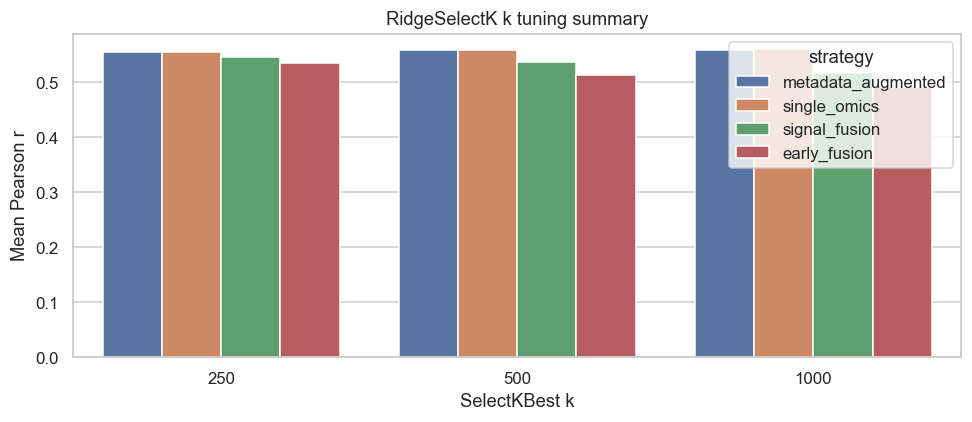

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=tuning_summary,
    x="k_features",
    y="mean_pearson",
    hue="strategy",
    ax=ax,
)
ax.set_xlabel("SelectKBest k")
ax.set_ylabel("Mean Pearson r")
ax.set_title("RidgeSelectK k tuning summary")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "ridge_selectk_k_tuning_summary.png", dpi=180, bbox_inches="tight")
plt.show()
